# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())
# Display summary statistics
print("\nSummary Statistics:")
df[['temperature', 'humidity', 'pressure']].describe()



Missing values:
 sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64

Summary Statistics:


,temperature,humidity,pressure
count,701548.000000,701548.000000,701548.000000
mean,24.754990,48.348949,94965.292500
std,14.013001,20.907247,2577.210945
min,-145.120000,0.000000,0.000000
25%,20.630000,34.140000,94528.017500
50%,24.780000,48.350000,95005.480000
75%,29.870000,62.940000,95405.132500
max,61.170000,100.000000,164926.750000


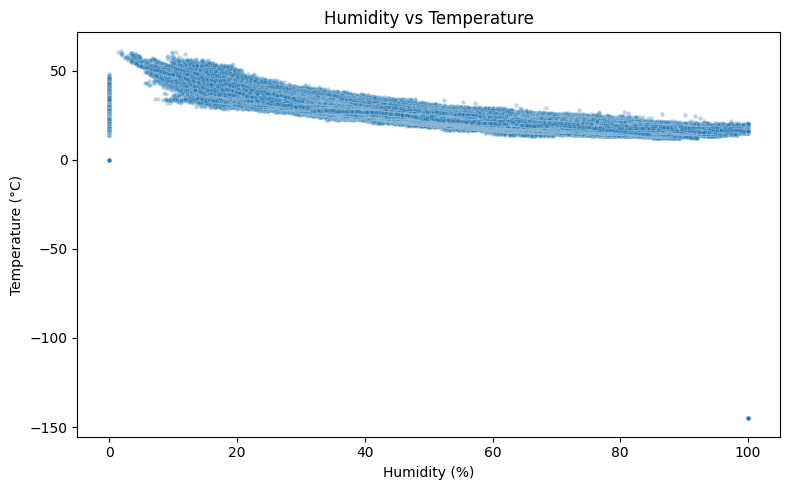

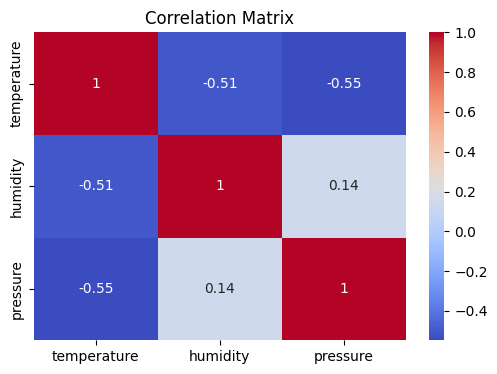

In [4]:
# Scatter plot to observe relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(x='humidity', y='temperature', data=df, alpha=0.3, s=10)
plt.title('Humidity vs Temperature')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df[['temperature', 'humidity', 'pressure']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Data Preprocessing

In [5]:
# Drop any rows with missing values
df_clean = df[(df['temperature'] > -50) & (df['temperature'] < 60)]
df_clean = df_clean[(df_clean['pressure'] > 50000)]
df_clean = df_clean.dropna()

print(f"Rows after cleaning: {len(df_clean)} (removed {len(df) - len(df_clean)} rows)")

# Define features and target
X = df_clean[['humidity']]       # Feature
y = df_clean['temperature']      # Target
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Rows after cleaning: 697543 (removed 4005 rows)
Train size: 558034, Test size: 139509


## Model Training

In [6]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")


# Predict
y_pred = model.predict(X_test)


Coefficient (slope): -0.2422
Intercept: 37.3249


## Evaluation


Mean Squared Error (MSE): 16.7405
Root Mean Squared Error (RMSE): 4.0915
R² Score: 0.5983


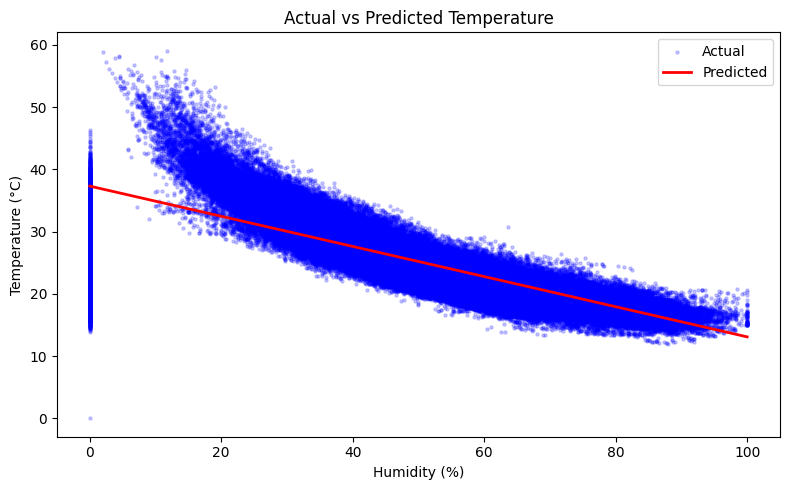

In [7]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.2, s=5, label='Actual')
plt.plot(X_test.sort_values('humidity'), 
         model.predict(X_test.sort_values('humidity')), 
         color='red', linewidth=2, label='Predicted')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.
